In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [59]:
df = pd.read_csv('data.csv')
print(df.shape)
df.head()

(6012, 144)


,R_fighter,B_fighter,Referee,date,location,Winner,title_bout,weight_class,B_avg_KD,B_avg_opp_KD,...,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
0,Adrian Yanez,Gustavo Lopez,Chris Tognoni,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Bantamweight,0.000,0.0,...,0,1,0,0,Orthodox,170.18,177.80,135.0,31.0,27.0
1,Trevin Giles,Roman Dolidze,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Middleweight,0.500,0.0,...,0,3,0,0,Orthodox,182.88,187.96,185.0,32.0,28.0
2,Tai Tuivasa,Harry Hunsucker,Herb Dean,2021-03-20,"Las Vegas, Nevada, USA",Red,False,Heavyweight,NaN,NaN,...,1,3,0,0,Southpaw,187.96,190.50,264.0,32.0,28.0
3,Cheyanne Buys,Montserrat Conejo,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenStrawweight,NaN,NaN,...,0,0,0,0,Switch,160.02,160.02,115.0,28.0,25.0
4,Marion Reneau,Macy Chiasson,Mark Smith,2021-03-20,"Las Vegas, Nevada, USA",Blue,False,WomenBantamweight,0.125,0.0,...,1,2,2,0,Orthodox,167.64,172.72,135.0,29.0,43.0


In [60]:
print("General info:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nDescriptive statistics:")
df.describe()

General info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6012 entries, 0 to 6011
Columns: 144 entries, R_fighter to R_age
dtypes: bool(1), float64(106), int64(28), object(9)
memory usage: 6.6+ MB
None

Missing values per column:
B_avg_opp_SUB_ATT           1427
B_avg_SUB_ATT               1427
B_avg_opp_TD_pct            1427
B_avg_TD_pct                1427
B_avg_opp_SIG_STR_pct       1427
B_avg_SIG_STR_pct           1427
B_avg_opp_KD                1427
B_avg_KD                    1427
B_avg_TOTAL_STR_landed      1427
B_avg_TOTAL_STR_att         1427
B_avg_opp_SIG_STR_landed    1427
B_avg_opp_SIG_STR_att       1427
B_avg_SIG_STR_landed        1427
B_avg_SIG_STR_att           1427
B_avg_opp_REV               1427
B_avg_REV                   1427
B_avg_opp_CLINCH_att        1427
B_avg_opp_CLINCH_landed     1427
B_avg_GROUND_att            1427
B_avg_GROUND_landed         1427
dtype: int64

Descriptive statistics:


,B_avg_KD,B_avg_opp_KD,B_avg_SIG_STR_pct,B_avg_opp_SIG_STR_pct,B_avg_TD_pct,B_avg_opp_TD_pct,B_avg_SUB_ATT,B_avg_opp_SUB_ATT,B_avg_REV,B_avg_opp_REV,...,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_Height_cms,R_Reach_cms,R_Weight_lbs,B_age,R_age
count,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.000000,4585.00000,4585.000000,...,6012.000000,6012.000000,6012.000000,6012.000000,6012.000000,6008.000000,5606.000000,6010.000000,5840.000000,5949.000000
mean,0.247476,0.176818,0.453310,0.434290,0.292650,0.268742,0.478884,0.409276,0.15673,0.141306,...,0.306886,1.251331,1.297572,0.796241,0.069195,178.991788,183.562347,170.686356,29.293151,29.598252
std,0.378509,0.324633,0.130458,0.132618,0.273628,0.267178,0.724229,0.653826,0.34199,0.322623,...,0.619485,1.681376,1.859955,1.355801,0.273980,8.812985,10.585313,35.724626,4.063297,4.167755
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,152.400000,152.400000,115.000000,18.000000,19.000000
25%,0.000000,0.000000,0.376489,0.351045,0.031250,0.033203,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,172.720000,177.800000,145.000000,26.000000,27.000000
50%,0.015625,0.000000,0.450000,0.427500,0.250000,0.200000,0.148468,0.098389,0.00000,0.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,180.340000,182.880000,170.000000,29.000000,29.000000
75%,0.500000,0.250000,0.527500,0.510000,0.500000,0.422812,0.750000,0.531250,0.12500,0.125000,...,0.000000,2.000000,2.000000,1.000000,0.000000,185.420000,190.500000,185.000000,32.000000,32.000000
max,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,8.000000,7.000000,4.00000,3.000000,...,5.000000,10.000000,11.000000,13.000000,2.000000,210.820000,213.360000,345.000000,51.000000,47.000000


Winner column values:
Winner
Red     3979
Blue    1923
Draw     110
Name: count, dtype: int64


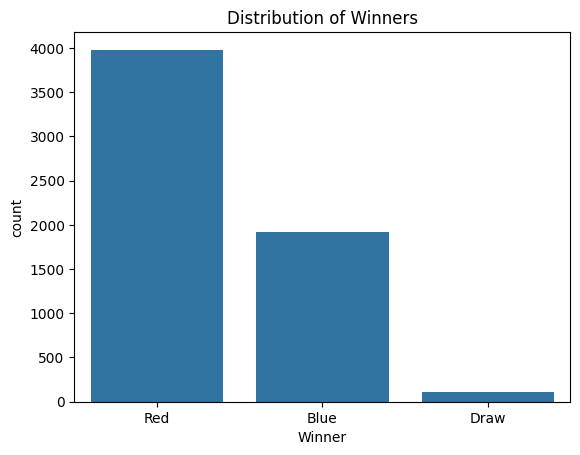

In [61]:
print("Winner column values:")
print(df['Winner'].value_counts())

sns.countplot(x='Winner', data=df)
plt.title('Distribution of Winners')
plt.show()

In [62]:
# Remove draws
df = df[df['Winner'] != 'Draw']
print("Shape after removing draws:", df.shape)
print("\nWinner distribution:")
print(df['Winner'].value_counts())

Shape after removing draws: (5902, 144)

Winner distribution:
Winner
Red     3979
Blue    1923
Name: count, dtype: int64


In [63]:
# Encode Winner: Red = 1, Blue = 0
le = LabelEncoder()
df['Winner'] = le.fit_transform(df['Winner'])
print("Winner encoded:")
print(df['Winner'].value_counts())

Winner encoded:
Winner
1    3979
0    1923
Name: count, dtype: int64


In [64]:
# Drop columns with too many missing values (more than 50%)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
print("Shape after dropping high-missing columns:", df.shape)

# Fill remaining missing values with median
df = df.fillna(df.median(numeric_only=True))
print("Missing values remaining:", df.isnull().sum().sum())

Shape after dropping high-missing columns: (5902, 144)
Missing values remaining: 121


In [65]:
from imblearn.over_sampling import SMOTE

# Select only numeric columns
X = df.select_dtypes(include=[np.number]).drop('Winner', axis=1)
y = df['Winner']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

Before SMOTE: {1: 3979, 0: 1923}
After SMOTE: {1: 3979, 0: 3979}


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (6366, 134)
Test set size: (1592, 134)


In [67]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Results
print("=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

=== Random Forest Results ===
Accuracy: 0.7795226130653267

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       780
           1       0.80      0.75      0.78       812

    accuracy                           0.78      1592
   macro avg       0.78      0.78      0.78      1592
weighted avg       0.78      0.78      0.78      1592



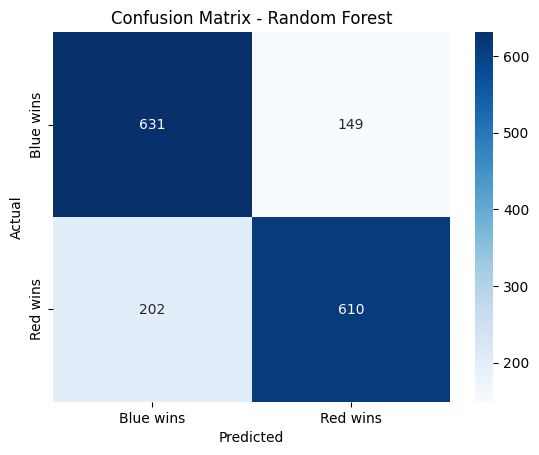

In [68]:
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Blue wins', 'Red wins'],
            yticklabels=['Blue wins', 'Red wins'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [69]:
from sklearn.preprocessing import StandardScaler

# Scale data (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_pred = lr_model.predict(X_test_scaled)

# Results
print("=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression Results ===
Accuracy: 0.717964824120603

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.67      0.70       780
           1       0.71      0.77      0.74       812

    accuracy                           0.72      1592
   macro avg       0.72      0.72      0.72      1592
weighted avg       0.72      0.72      0.72      1592



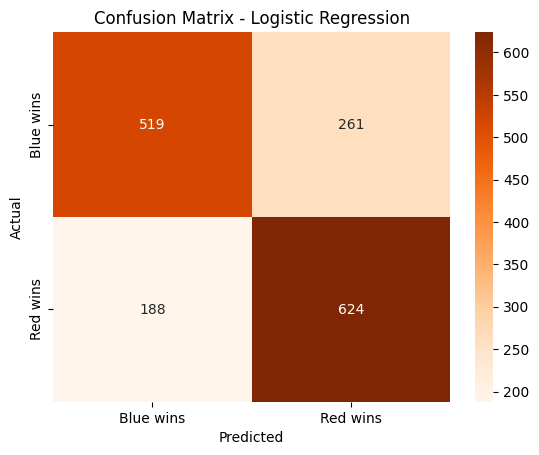

In [70]:
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Blue wins', 'Red wins'],
            yticklabels=['Blue wins', 'Red wins'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

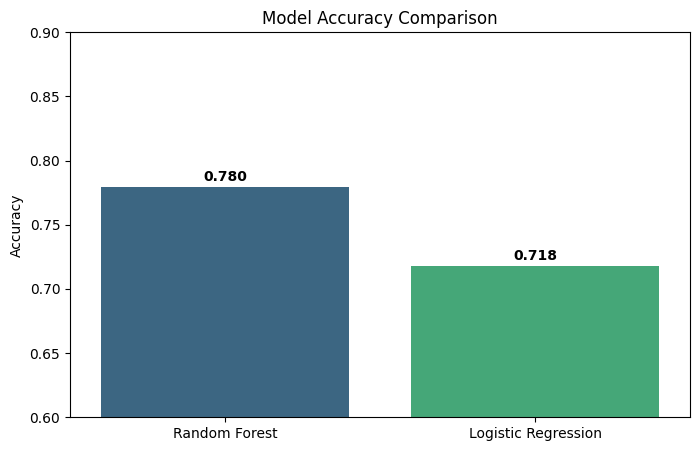

In [71]:
models = ['Random Forest', 'Logistic Regression']
accuracies = [accuracy_score(y_test, rf_pred), accuracy_score(y_test, lr_pred)]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0.6, 0.9)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)